<a href="https://colab.research.google.com/github/Saddeee/kex/blob/main/KEX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import requests
import zipfile
import io
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt

def load_data():
  # URL for MovieLens 1M dataset
  url = "http://files.grouplens.org/datasets/movielens/ml-1m.zip"

  # Download the zip file
  response = requests.get(url)
  zip_file = zipfile.ZipFile(io.BytesIO(response.content))

  # Extract and load the 'users.dat' file
  # The file is pipe-separated and has no header, so we define columns
  users_data = zip_file.read('ml-1m/users.dat').decode('latin-1')
  users = pd.read_csv(io.StringIO(users_data), sep='::', engine='python',
                      names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'])

  # Extract and load the 'movies.dat' file
  movies_data = zip_file.read('ml-1m/movies.dat').decode('latin-1')
  movies = pd.read_csv(io.StringIO(movies_data), sep='::', engine='python',
                       names=['MovieID', 'Title', 'Genres'])

  # Extract and load the 'ratings.dat' file
  ratings_data = zip_file.read('ml-1m/ratings.dat').decode('latin-1')
  ratings = pd.read_csv(io.StringIO(ratings_data), sep='::', engine='python',
                        names=['UserID', 'MovieID', 'Rating', 'Timestamp'])

  print("MovieLens data loaded successfully!")
  return users, movies, ratings

users_df, movies_df, ratings_df = load_data()

print("\nUsers DataFrame Head:")
display(users_df.head())

print("\nMovies DataFrame Head:")
display(movies_df.head())

print("\nRatings DataFrame Head:")
display(ratings_df.head())


MovieLens data loaded successfully!

Users DataFrame Head:


,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455



Movies DataFrame Head:


,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy



Ratings DataFrame Head:


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [ ]:
"""
class Rating:
  def __init__(self, user_id, movie_id, rating, timestamp):
    self.user_id = user_id
    self.movie_id = movie_id
    self.rating = rating
    self.timestamp = timestamp
  def __str__(self):
    return f"{self.user_id}, {self.movie_id}, {self.rating}, {self.timestamp}"

# Vad vi borde göra istället: Tag 90 % av varje användares ratings till training och resterande 10 % till validation kanske
#consider only using latest rating of a user då man kan ändra sig något vi kjan ha med i diskusion

# Get first 1000 unique users
first_users = ratings_df["UserID"].unique()[:100]

# Take all reviews for those users
ratings_subset = ratings_df[ratings_df["UserID"].isin(first_users)]

# Users for each review
users = ratings_subset["UserID"].to_numpy().astype(int)  # one entry per review
items = ratings_subset["MovieID"].to_numpy().astype(int)
ratings = ratings_subset["Rating"].to_numpy()

print(np.shape(ratings))


training_data_share_of_ratings = 0.5

ratings = ratings[:int(len(ratings) * training_data_share_of_ratings)]

latent_space_dim = 2

b_items = np.zeros(ratings_df.MovieID.max() + 1)
q_items = np.random.rand(ratings_df.MovieID.max() + 1, latent_space_dim)

b_users = np.zeros(ratings_df.UserID.max() + 1)
p_users = np.random.rand(ratings_df.UserID.max() + 1, latent_space_dim)

#convert explcit to implicit
#ratings_df['Rating'] = ratings_df['Rating'].apply(lambda x : 1 if x >= 0 else 0)
#print(ratings_df.head())


ratings_numpy = ratings_df.to_numpy()

#slumpa users tag icke rating
def data_preprocessing_sample_negagtive():
  global ratings_numpy
  ratings_numpy = ratings_numpy[ratings_numpy[:, 0] < 100]
  user_to_rating = {}
  rating_preprocessed = np.zeros(np.shape(ratings_numpy))
  test_set = {}
  for row in ratings_numpy:
    user_id = row[0]
    movie_id = row[1]
    ratings = row[2]
    timestamp = row[3]
    ratings = Rating(user_id, movie_id, ratings, timestamp)
    #print(ratings)
    user_to_rating[user_id] = user_to_rating.get(user_id, [])
    user_to_rating[user_id].append(ratings)

  for user,values in user_to_rating.items():
    len_ratings = len(values)
    #sample unseen for that user
    ratings_unseen = set()
    while len(ratings_unseen) < len_ratings:
      sample = np.random.randint(0, movies_df.MovieID.max() + 1)
      if sample not in ratings_unseen:
        for rating in values:
          if rating.movie_id == sample:
            break
        else:
          temp_rating = Rating(user, sample, 0, -1)
          ratings_unseen.add(temp_rating)

    #convert 1D ratigns list -> 2D numpy
    #  1. Extract the data into a list of lists
    new_data = [ [r.user_id, r.movie_id, r.rating, r.timestamp]  for r in ratings_unseen]

    # 2. Convert to NumPy
    ratings_unseen_array = np.array(new_data)

    # 3. Combine with your existing array
    # (Assuming ratings_numpy is already a NumPy array)
    ratings_numpy = np.vstack((ratings_numpy, ratings_unseen_array))
  return ratings_numpy

#ratings_numpy = data_preprocessing_sample_negagtive()


def data_preprocessing_leave_one_out():
  #exclude single people from data.
  global ratings_numpy
  #leave one out
  #cut ratings numpy
  ratings_numpy = ratings_numpy[ratings_numpy[:, 0] < 100]
  user_to_rating = {}
  rating_preprocessed = np.zeros(np.shape(ratings_numpy))
  test_set = {}
  for row in ratings_numpy:
    user_id = row[0]
    movie_id = row[1]
    ratings = row[2]
    timestamp = row[3]
    ratings = Rating(user_id, movie_id, ratings, timestamp)
    #print(ratings)
    user_to_rating[user_id] = user_to_rating.get(user_id, [])
    user_to_rating[user_id].append(ratings)

  for key, value in user_to_rating.items():
    if(len(value) == 1):
      del user_to_rating[key]
    #print(value[0])
    value.sort(key=lambda x: x.timestamp)
    test_set[key] = value[-1]
    value = value[:-1]
  return user_to_rating, test_set

training_split, test_set = data_preprocessing_leave_one_out()


for key, value in training_split.items():
  print(key)
  for i in value:
    print(i)
for key, value in test_set.items():
    print(i)
"""












'\nclass Rating:\n  def __init__(self, user_id, movie_id, rating, timestamp):\n    self.user_id = user_id\n    self.movie_id = movie_id\n    self.rating = rating\n    self.timestamp = timestamp\n  def __str__(self):\n    return f"{self.user_id}, {self.movie_id}, {self.rating}, {self.timestamp}"\n\n# Vad vi borde göra istället: Tag 90 % av varje användares ratings till training och resterande 10 % till validation kanske\n#consider only using latest rating of a user då man kan ändra sig något vi kjan ha med i diskusion\n\n# Get first 1000 unique users\nfirst_users = ratings_df["UserID"].unique()[:100]\n\n# Take all reviews for those users\nratings_subset = ratings_df[ratings_df["UserID"].isin(first_users)]\n\n# Users for each review\nusers = ratings_subset["UserID"].to_numpy().astype(int)  # one entry per review\nitems = ratings_subset["MovieID"].to_numpy().astype(int)\nratings = ratings_subset["Rating"].to_numpy()\n\nprint(np.shape(ratings))\n\n\ntraining_data_share_of_ratings = 0.5\n\n

In [ ]:
# Rating class
class Rating:

    def __init__(self, user_id, movie_id, rating, timestamp):

        self.user_id = user_id
        self.movie_id = movie_id
        self.rating = rating
        self.timestamp = timestamp

    def __str__(self):

        return f"{self.user_id}, {self.movie_id}, {self.rating}, {self.timestamp}"


# -----------------------------
# Leave-One-Out Split
# -----------------------------
def data_preprocessing_leave_one_out(ratings_numpy):

    if not isinstance(ratings_numpy, dict):
      user_to_rating = defaultdict(list)
      for row in ratings_numpy:
          user_id = int(row[0])
          movie_id = int(row[1])
          rating = float(row[2])
          timestamp = int(row[3])
          r = Rating(user_id, movie_id, rating, timestamp)
          user_to_rating[user_id].append(r)
      train = {}
      test = {}
      for user, values in user_to_rating.items():
          if len(values) < 2:
              continue
          values.sort(key=lambda x: x.timestamp)
          test[user] = values[-1]
          train[user] = values[:-1]
      return train, test
    else:
      user_to_rating = defaultdict(list)
      for user, ratings in ratings_numpy.items():
        for rating in ratings:
          r = Rating(user, rating.movie_id, rating.rating, rating.timestamp)
          user_to_rating[user].append(r)
      train = {}
      test = {}
      for user, values in user_to_rating.items():
          if len(values) < 2:
              continue
          values.sort(key=lambda x: x.timestamp)
          test[user] = values[-1]
          train[user] = values[:-1]
      return train, test


# -----------------------------
# Negative Sampling (implicit training only)
# -----------------------------
def add_negative_samples(train_dict, num_movies):
    implicit_train = {}
    for user, values in train_dict.items():
        rated_movies = {r.movie_id for r in values}
        #new_values = list(values) hmmm are we usign raitng 1-5?
        new_values = []
        for r in values:
          new_values.append(Rating(r.user_id, r.movie_id, 1, r.timestamp))
        num_negatives = len(values)
        negatives = set()
        while len(negatives) < num_negatives:
            sample = np.random.randint(1, num_movies + 1)
            if sample not in rated_movies:
                negatives.add(sample)
        for movie in negatives:
            new_values.append(Rating(user, movie, 0, -1))
        implicit_train[user] = new_values
    return implicit_train

In [ ]:
import numpy as np
import tensorflow as tf
from tqdm import tqdm

# -----------------------------
# RMSE
# -----------------------------
def rmse(test, b_users, b_items, p_users, q_items, global_mean):
    errors = []
    for user, r in tqdm(test.items(), desc="RMSE", unit="user"):
        pred = predict(user, r.movie_id, b_users, b_items, p_users, q_items, global_mean)
        errors.append((r.rating - pred)**2)
    return np.sqrt(np.mean(errors))


# -----------------------------
# HR@K — NeuMF (batched)
# -----------------------------
def evaluate_implicit_NeuMF_hr(train, test, num_movies, model, K=5, batch_size=512):
    all_users, all_movies, user_order = [], [], []

    for user, r in tqdm(test.items(), desc="Building candidates", unit="user"):
        rated_movies = {x.movie_id for x in train[user]}

        negatives = set()
        while len(negatives) < 10:
            movie = np.random.randint(1, num_movies)
            if movie not in rated_movies and movie != r.movie_id:
                negatives.add(movie)

        candidates = list(negatives) + [r.movie_id]
        all_users.extend([user] * len(candidates))
        all_movies.extend(candidates)
        user_order.append((user, r.movie_id, len(candidates)))

    users_tensor  = tf.constant(all_users,  dtype=tf.int32)
    movies_tensor = tf.constant(all_movies, dtype=tf.int32)

    all_scores = []
    batches = range(0, len(all_users), batch_size)
    for start in tqdm(batches, desc="Predicting HR@K batches", unit="batch"):
        preds = model(
            [users_tensor[start:start + batch_size],
             movies_tensor[start:start + batch_size]],
            training=False
        )
        all_scores.append(preds)

    all_scores = tf.concat(all_scores, axis=0).numpy().flatten()

    hits, idx = 0, 0
    for user, true_movie_id, n_candidates in tqdm(user_order, desc="Scoring HR@K", unit="user"):
        user_scores = all_scores[idx : idx + n_candidates]
        user_movies = all_movies[idx : idx + n_candidates]
        idx += n_candidates

        top_k = [user_movies[i] for i in np.argsort(user_scores)[::-1][:K]]
        if true_movie_id in top_k:
            hits += 1

    return hits / len(test)


# -----------------------------
# NDCG — MF (explicit)
# -----------------------------
def ndcg_from_ranking(ranked_items, target_item, rel):
    if target_item not in ranked_items:
        return 0
    rank = ranked_items.index(target_item)
    dcg  = (2**rel - 1) / np.log2(rank + 2)
    idcg = (2**rel - 1) / np.log2(2)
    return dcg / idcg


def evaluate_implicit_ndcg(train, test, num_movies, b_users, b_items, p_users, q_items, global_mean, K=10):
    mean = 0
    for user, r in tqdm(test.items(), desc="Implicit NDCG", unit="user"):
        rated_movies = {x.movie_id for x in train[user]}

        negatives = set()
        while len(negatives) < K:
            movie = np.random.randint(1, num_movies + 1)
            if movie not in rated_movies and movie != r.movie_id:
                negatives.add(movie)

        candidates = list(negatives) + [r.movie_id]
        scores = np.zeros(K + 1)

        for i, movie in enumerate(candidates):
            scores[i] = predict(user, i, b_users, b_items, p_users, q_items, global_mean)

        ranking   = np.argsort(scores)[::-1]
        pos_index = candidates.index(r.movie_id)
        rank      = np.where(ranking == pos_index)[0][0]

        dcg  = 1 / np.log2(rank + 2)
        idcg = 1 / np.log2(2)
        mean += dcg / idcg

    return mean / len(test)


def evaluate_explicit_ndcg(train, test, num_movies, b_users, b_items, p_users, q_items, global_mean, K=10):
    mean = 0
    for user, r in tqdm(test.items(), desc="Explicit NDCG", unit="user"):
        rated_movies = {x.movie_id for x in train[user]}

        negatives = set()
        while len(negatives) < K:
            movie = np.random.randint(1, num_movies + 1)
            if movie not in rated_movies and movie != r.movie_id:
                negatives.add(movie)

        candidates = list(negatives) + [r.movie_id]
        scores     = np.zeros(K + 1)

        for i, movie in enumerate(candidates):
            scores[i] = predict(user, i, b_users, b_items, p_users, q_items, global_mean)

        ranking      = np.argsort(scores)[::-1]
        ranked_items = [candidates[i] for i in ranking]
        mean        += ndcg_from_ranking(ranked_items, r.movie_id, r.rating)

    return mean / len(test)


# -----------------------------
# NDCG — GMF/NeuMF (batched)
# -----------------------------
def evaluate_implicit_ndcg_GMF(train, test, num_movies, model, K=10, batch_size=512):
    all_users, all_movies, user_order = [], [], []

    for user, r in tqdm(test.items(), desc="Building candidates", unit="user"):
        rated_movies = {x.movie_id for x in train[user]}

        negatives = set()
        while len(negatives) < K:
            movie = np.random.randint(1, num_movies)  # ← fixed
            if movie not in rated_movies and movie != r.movie_id:
                negatives.add(movie)

        candidates = list(negatives) + [r.movie_id]
        all_users.extend([user] * len(candidates))
        all_movies.extend(candidates)
        user_order.append((user, r.movie_id, len(candidates)))

    users_tensor  = tf.constant(all_users,  dtype=tf.int32)
    movies_tensor = tf.constant(all_movies, dtype=tf.int32)

    all_scores = []
    batches = range(0, len(all_users), batch_size)
    for start in tqdm(batches, desc="Predicting NDCG batches", unit="batch"):
        preds = model(
            [users_tensor[start:start + batch_size],
             movies_tensor[start:start + batch_size]],
            training=False
        )
        all_scores.append(preds)

    all_scores = tf.concat(all_scores, axis=0).numpy().flatten()

    mean, idx = 0.0, 0
    for user, true_movie_id, n_candidates in tqdm(user_order, desc="Scoring NDCG", unit="user"):
        user_scores = all_scores[idx : idx + n_candidates]
        candidates  = all_movies[idx : idx + n_candidates]
        idx        += n_candidates

        ranking   = np.argsort(user_scores)[::-1]
        pos_index = list(candidates).index(true_movie_id)
        rank      = np.where(ranking == pos_index)[0][0]

        dcg  = 1 / np.log2(rank + 2)
        idcg = 1 / np.log2(2)
        mean += dcg / idcg

    return mean / len(test)


# -----------------------------
# NDCG wrapper
# -----------------------------
def evaluate_ndcg_wrapper(train, test, num_movies, b_users, b_items, p_users, q_items, flag, global_mean, K=10):
    if flag == "implicit":
        return evaluate_implicit_ndcg(train, test, num_movies, b_users, b_items, p_users, q_items, global_mean, K)
    else:
        return evaluate_explicit_ndcg(train, test, num_movies, b_users, b_items, p_users, q_items, global_mean, K)

In [ ]:
# -----------------------------
# Subset of users
# -----------------------------
first_users = ratings_df["UserID"].unique()[:100]
ratings_subset = ratings_df[ratings_df["UserID"].isin(first_users)]
ratings_numpy = ratings_subset.to_numpy()

tmp_training_split, test_set = data_preprocessing_leave_one_out(ratings_numpy)
training_split, validation_set = data_preprocessing_leave_one_out(tmp_training_split)

implicit_training_split = add_negative_samples(training_split,ratings_df.MovieID.max())

# -----------------------------
# Matrix Factorization Params
# -----------------------------
#latent_space_dim = 20
num_users = ratings_df.UserID.max() + 1
num_items = ratings_df.MovieID.max() + 1


def calculate_global_mean(train_data):
    total_rating = 0
    count = 0
    for user, values in train_data.items():
        for r in values:
            total_rating += r.rating
            count += 1
    return total_rating / count if count > 0 else 0

def predict(u, i, b_users, b_items, p_users, q_items, global_mean):
    return global_mean + b_users[u] + b_items[i] + np.dot(p_users[u], q_items[i])

# -----------------------------
# Training
# -----------------------------
""""
def train(train_data, b_users, b_items, p_users, q_items, epochs=10, lr=0.01, reg=0.02):
    samples = []
    for user, values in train_data.items():
        for r in values:
            samples.append((r.user_id, r.movie_id, r.rating))
    for epoch in range(epochs):
        random.shuffle(samples)
        loss = 0
        for u,i,r in samples:
            pred = predict(u,i, b_users, b_items, p_users, q_items)
            err = r - pred
            loss += err**2
            b_users[u] += lr * (err - reg*b_users[u])
            b_items[i] += lr * (err - reg*b_items[i])
            pu = p_users[u]
            qi = q_items[i]
            p_users[u] += lr*(err*qi - reg*pu)
            q_items[i] += lr*(err*pu - reg*qi)
        loss /= len(samples)
        yield loss  # return loss each epoch
"""

def train(train_data, b_users, b_items, p_users, q_items, global_mean, epochs=10, lr=0.01, reg=0.02):
    samples = []
    for user, values in train_data.items():
        for r in values:
            samples.append((r.user_id, r.movie_id, r.rating))

    for epoch in range(epochs):
        random.shuffle(samples)
        loss = 0
        for u, i, r in samples:
            pred = predict(u, i, b_users, b_items, p_users, q_items, global_mean)
            err = r - pred
            loss += err**2

            # Copy the old parameters to avoid the in-place update trap
            pu = p_users[u].copy()
            qi = q_items[i].copy()

            b_users[u] += lr * (err - reg * b_users[u])
            b_items[i] += lr * (err - reg * b_items[i])

            p_users[u] += lr * (err * qi - reg * pu)
            q_items[i] += lr * (err * pu - reg * qi)

        loss /= len(samples)
        yield loss
#hyperparameter tuning
"""
def hyperparameter_tuning(training_split, validation_set, flag, num_users, num_items):
    K_values = [8, 16, 32, 64]
    best_k = 0
    # Change logic to "Higher is Better" for NDCG
    best_ndcg = -np.inf


    best_params = {}
    results = {}
    best_eval_for_k = {}

    for k in K_values:
        b_items = np.zeros(num_items+1)
        q_items = np.random.normal(0, 0.1, (num_items+1, k))
        b_users = np.zeros(num_users+1)
        p_users = np.random.normal(0, 0.1, (num_users+1, k))

        current_k_losses = []

        best_local = -np.inf

        for epoch, loss in enumerate(train(training_split, b_users, b_items, p_users, q_items)):
            current_ndcg = evaluate_ndcg_wrapper(training_split, validation_set, num_items, b_users, b_items, p_users, q_items, flag)
            current_k_losses.append(loss)
            if current_ndcg > best_local:
                best_local = current_ndcg
                best_eval_for_k[k] = current_ndcg

            # Update best parameters if NDCG improved
            if current_ndcg > best_ndcg:
                best_ndcg = current_ndcg
                best_k = k
                # Capture the state of the best model
                best_params = {
                    'b_items': b_items.copy(),
                    'q_items': q_items.copy(),
                    'b_users': b_users.copy(),
                    'p_users': p_users.copy()
                }


        results[k] = current_k_losses

    print(f"Best K found: {best_k}")
    print(f"Highest NDCG: {best_ndcg}")

    return best_params['b_items'], best_params['q_items'], best_params['b_users'], best_params['p_users'], results, best_eval_for_k
"""
def hyperparameter_tuning(training_split, validation_set, flag, num_users, num_items):
    K_values = [8, 16, 32, 64]
    best_k = 0
    best_ndcg = -np.inf

    best_params = {}
    results = {}
    best_eval_for_k = {}

    #  Calculate global mean once
    global_mean = calculate_global_mean(training_split)

    for k in K_values:
        b_items = np.zeros(num_items+1)
        q_items = np.random.normal(0, 0.1, (num_items+1, k))
        b_users = np.zeros(num_users+1)
        p_users = np.random.normal(0, 0.1, (num_users+1, k))

        current_k_losses = []
        best_local = -np.inf


        for epoch, loss in enumerate(train(training_split, b_users, b_items, p_users, q_items, global_mean)):

            current_ndcg = evaluate_ndcg_wrapper(training_split, validation_set, num_items, b_users, b_items, p_users, q_items, flag, global_mean=global_mean)

            current_k_losses.append(loss)
            if current_ndcg > best_local:
                best_local = current_ndcg
                best_eval_for_k[k] = current_ndcg

            # Update best parameters if NDCG improved
            if current_ndcg > best_ndcg:
                best_ndcg = current_ndcg
                best_k = k
                best_params = {
                    'b_items': b_items.copy(),
                    'q_items': q_items.copy(),
                    'b_users': b_users.copy(),
                    'p_users': p_users.copy()
                }

        results[k] = current_k_losses

    print(f"Best K found: {best_k}")
    print(f"Highest NDCG: {best_ndcg}")

    return best_params['b_items'], best_params['q_items'], best_params['b_users'], best_params['p_users'], results, best_eval_for_k





def hyperparameter_tuning_ncf(training_split, validation_set, flag, num_users, num_items):
    K_values = [8, 16, 32, 64]
    best_k = 0
    best_ndcg = -np.inf

    best_params = {}
    best_model = None
    results = {}
    best_eval_for_k = {}

    #  Calculate global mean once
    global_mean = calculate_global_mean(training_split)

    for k in K_values:



        for i in range(10):

          ## model
          model = get_model_GMF(num_users, num_items, k)

          current_k_losses = []
          best_local = -np.inf


          #for epoch, loss in enumerate(train(training_split, b_users, b_items, p_users, q_items, global_mean)):

          ##for i in range(0, epoch):

          model = train_GMF(training_split, num_items)

          #current_ndcg = evaluate_ndcg_wrapper(training_split, validation_set, num_items, b_users, b_items, p_users, q_items, flag, global_mean=global_mean)
          current_ndcg = evaluate_implicit_ndcg_GMF(training_split, validation_set, num_items, model)

          current_k_losses.append(loss)
          if current_ndcg > best_local:
              best_local = current_ndcg
              best_eval_for_k[k] = current_ndcg

          # Update best parameters if NDCG improved
          if current_ndcg > best_ndcg:
              best_ndcg = current_ndcg
              best_k = k
              best_model = model


        results[k] = current_k_losses

    print(f"Best K found: {best_k}")
    print(f"Highest NDCG: {best_ndcg}")

    return model, results, best_eval_for_k





In [ ]:



"""

explicit_losses = []
explicit_rmse = []
explicit_ndgc = []

implicit_losses = []
implicit_rmse = []
implicit_hr = []

# -----------------------------
# EXPERIMENT 1: Explicit SVD
# -----------------------------
print("\n---- Explicit SVD ----\n")
b_items, q_items, b_users,p_users, results, best_eval_for_k = hyperparameter_tuning(training_split, validation_set, "explicit", num_users, num_items)
test_rmse = rmse(test_set, b_users, b_items, p_users, q_items)
explicit_rmse.append(test_rmse)
explicit_ndgc.append(evaluate_explicit_ndcg(training_split, test_set, ratings_df.MovieID.max(), b_users, b_items, p_users, q_items, K=10))

#print eval for each k
for k, ndcg in best_eval_for_k.items():
    print(f"K: {k}, NDCG: {ndcg}")
#plot eval x is k and y is ndcg
plt.figure()
plt.plot(list(best_eval_for_k.keys()), list(best_eval_for_k.values()))
plt.title("eval")

print("Test RMSE:", test_rmse)
print()


plt.figure()
plt.plot(explicit_ndgc, label="Exokicit NDGC")
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -----------------------------
# EXPERIMENT 2: Implicit SVD
# -----------------------------
print("\n---- Implicit SVD ----\n")
for i in test_set:
  ratingobj = test_set[i]
  ratingobj.rating = 1

for i in validation_set:
  ratingobj = validation_set[i]
  ratingobj.rating = 1

b_items, q_items, b_users,p_users, results, best_eval_for_k = hyperparameter_tuning(implicit_training_split, validation_set, "implicit", num_users, num_items)
test_rmse = rmse(test_set, b_users, b_items, p_users, q_items)
#hr = evaluate_implicit(training_split, test_set, ratings_df.MovieID.max())

hr = evaluate_implicit_ndcg(training_split, test_set, ratings_df.MovieID.max(), b_users, b_items, p_users, q_items, K=10)
implicit_rmse.append(test_rmse)
implicit_hr.append(hr)
print("Test RMSE:", test_rmse)
print("HitRate@10:", hr)
print()


#print eval for each k
for k, ndcg in best_eval_for_k.items():
    print(f"K: {k}, NDCG: {ndcg}")
#plot eval x is k and y is ndcg
plt.figure()
plt.plot(list(best_eval_for_k.keys()), list(best_eval_for_k.values()))
plt.title("eval")


# -----------------------------
# PLOTS
# -----------------------------
plt.figure()
plt.plot(explicit_losses, label="Explicit Loss")
plt.plot(implicit_losses, label="Implicit Loss")
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(explicit_rmse, label="Explicit RMSE")
plt.plot(implicit_rmse, label="Implicit RMSE")
plt.title("Validation RMSE per Epoch")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.show()

plt.figure()
plt.plot(implicit_hr)
plt.title("Implicit HitRate@10 per Epoch")
plt.xlabel("Epoch")
plt.ylabel("HitRate")
plt.show()

"""

print(ndcg_from_ranking([1, 2,100], target_item=100, rel=1.0))



0.5


In [ ]:
'''

import numpy as np

# --- MUST DO THIS BEFORE ANY OTHER IMPORTS ---
# RecBole uses these internally; they must exist before recbole is loaded.
if not hasattr(np, 'float'): np.float = float
if not hasattr(np, 'int'): np.int = int
if not hasattr(np, 'bool'): np.bool = bool
if not hasattr(np, 'unicode_'): np.unicode_ = np.str_
if not hasattr(np, 'unicode'): np.unicode = np.str_
# ---------------------------------------------

import torch
from functools import partial

# Now you can safely import recbole
from recbole.quick_start import run_recbole

# PyTorch 2.6+ fix (RecBole saves state_dicts that include non-tensor data)
torch.load = partial(torch.load, weights_only=False)

run_recbole(model='NeuMF', dataset='ml-100k')

'''

"\n\nimport numpy as np\n\n# --- MUST DO THIS BEFORE ANY OTHER IMPORTS ---\n# RecBole uses these internally; they must exist before recbole is loaded.\nif not hasattr(np, 'float'): np.float = float\nif not hasattr(np, 'int'): np.int = int\nif not hasattr(np, 'bool'): np.bool = bool\nif not hasattr(np, 'unicode_'): np.unicode_ = np.str_\nif not hasattr(np, 'unicode'): np.unicode = np.str_\n# ---------------------------------------------\n\nimport torch\nfrom functools import partial\n\n# Now you can safely import recbole\nfrom recbole.quick_start import run_recbole\n\n# PyTorch 2.6+ fix (RecBole saves state_dicts that include non-tensor data)\ntorch.load = partial(torch.load, weights_only=False)\n\nrun_recbole(model='NeuMF', dataset='ml-100k')\n\n"

In [ ]:
import keras
from keras import initializers
from keras import backend as K
from keras.models import Sequential, Model, load_model, save_model
from keras.layers import Dense, Lambda, Activation,Concatenate
from keras.layers import Embedding, Input, Dense, Reshape, Flatten, Multiply # changed merge -> Multiply
from keras.optimizers import Adagrad, Adam, SGD, RMSprop
from keras.regularizers import l2
from time import time

def keras_train_instaces(train_dict, num_items, num_negatives =4):
  user_input, item_input, labels = [],[],[]
  for user, ratings in train_dict.items():
    postive_items = {r.movie_id for r in ratings}
    for r in ratings:
      user_input.append(user)
      item_input.append(r.movie_id)
      labels.append(1)
      #handle negative
      for _ in range(num_negatives):
        j = np.random.randint(1, num_items)
        while j in postive_items:
          j = np.random.randint(1, num_items)
        user_input.append(user)
        item_input.append(j)
        labels.append(0)
  return np.array(user_input), np.array(item_input), np.array(labels)

def init_normal(shape, name=None):
    return initializers.normal(shape, stddev=0.01, name=name) # Changed: scale to stddev

def get_model_GMF(num_users, num_items, latent_dim, regs=[0,0]):
    # Input variables
    user_input = Input(shape=(1,), dtype='int32', name = 'user_input')
    item_input = Input(shape=(1,), dtype='int32', name = 'item_input')


    MF_Embedding_User = Embedding(input_dim = num_users, output_dim = latent_dim, name = 'user_embedding',
                                   embeddings_initializer="uniform", embeddings_regularizer = l2(regs[0]), input_length=1) # Changed: init, W_regularizer
    MF_Embedding_Item = Embedding(input_dim = num_items, output_dim = latent_dim, name = 'item_embedding',
                                   embeddings_initializer="uniform", embeddings_regularizer = l2(regs[1]), input_length=1) # Changed: init, W_regularizer

    # Crucial to flatten an embedding vector!
    user_latent = Flatten()(MF_Embedding_User(user_input))
    item_latent = Flatten()(MF_Embedding_Item(item_input))

    # Element-wise product of user and item embeddings
    predict_vector = Multiply()([user_latent, item_latent]) # siwthc merge -> Mulitply

    # Final prediction layer
    #prediction = Lambda(lambda x: K.sigmoid(K.sum(x)), output_shape=(1,))(predict_vector)
    prediction = Dense(1, activation='sigmoid', kernel_initializer='lecun_uniform', name = 'prediction')(predict_vector) # Changed: init to kernel_initializer

    model = Model(inputs=[user_input, item_input], outputs=prediction) # Changed: input to inputs, output to outputs

    return model


def train_GMF(train_dict, num_items):

      # args = parse_args() # This function is not defined in the provided code snippet
      # Placeholder values for args for demonstration. You'd need to define parse_args() or pass these values.
      class Args:
          def __init__(self):
              self.num_factors = 8
              self.regs = '[0,0]'
              self.num_neg = 4
              self.learner = 'sgd'
              self.lr = 0.01
              self.epochs = 10
              self.batch_size = 10
              self.verbose = 1
              self.dataset = 'ml-1m'
              self.path = ''
              self.out = 0
      args = Args()

      num_factors = args.num_factors
      regs = eval(args.regs)
      num_negatives = args.num_neg
      learner = args.learner
      learning_rate = args.lr
      epochs = args.epochs
      batch_size = args.batch_size
      verbose = args.verbose

      topK = 10
      evaluation_threads = 1 #mp.cpu_count()
      print("GMF arguments: %s" %(args.__dict__))
      model_out_file = 'Pretrain/%s_GMF_%d_%d.h5' %(args.dataset, num_factors, time())

      # Loading data
      # t1 = time()
      # dataset = Dataset(args.path + args.dataset) # Dataset and trainMatrix are not defined
      # train, testRatings, testNegatives = dataset.trainMatrix, dataset.testRatings, dataset.testNegatives
      # num_users, num_items = train.shape
      # print("Load data done [%.1f s]. #user=%d, #item=%d, #train=%d, #test=%d"
            # %(time()-t1, num_users, num_items, train.nnz, len(testRatings)))
      # Skipping dataset loading as it's commented out/not fully defined.
      # Assuming num_users and num_items are already defined or passed.
      # For this example, I'll use the num_users and num_items from the notebook state.


      # Build model
      model = get_model_GMF(num_users, num_items, num_factors, regs)
      model.compile(optimizer=SGD(learning_rate=learning_rate), loss='binary_crossentropy') # Changed lr to learning_rate
      #print(model.summary())

      # Init performance
      t1 = time()
      ##(hits, ndcgs) = evaluate_model(model, testRatings, testNegatives, topK, evaluation_threads)
      hr, ndcg = 0, 0 # Placeholder for hr, ndcg since evaluate_model is not defined
      #mf_embedding_norm = np.linalg.norm(model.get_layer('user_embedding').get_weights())+np.linalg.norm(model.get_layer('item_embedding').get_weights())
      #p_norm = np.linalg.norm(model.get_layer('prediction').get_weights()[0])
      print('Init: HR = %.4f, NDCG = %.4f\t [%.1f s]' % (hr, ndcg, time()-t1))

      # Train model
      best_hr, best_ndcg, best_iter = hr, ndcg, -1
      for epoch in range(epochs): # Changed xrange to range
          t1 = time()
          # Generate training instances
          user_input, item_input, labels = keras_train_instaces(train_dict, num_items) #get_train_instances(train, num_negatives)

          # Training
          hist = model.fit([user_input, item_input], labels, epochs=1, batch_size = batch_size, verbose="auto", shuffle=True) # Changed nb_epoch to epochs
          t2 = time()

          # Evaluation
          '''
          if epoch %verbose == 0:
              (hits, ndcgs) = evaluate_model(model, testRatings, testNegatives, topK, evaluation_threads)
              hr, ndcg, loss = np.array(hits).mean(), np.array(ndcgs).mean(), hist.history['loss'][0]
              print('Iteration %d [%.1f s]: HR = %.4f, NDCG = %.4f, loss = %.4f [%.1f s]'
                    % (epoch,  t2-t1, hr, ndcg, loss, time()-t2))
              if hr > best_hr:
                  best_hr, best_ndcg, best_iter = hr, ndcg, epoch
                  if args.out > 0:
                      model.save_weights(model_out_file, overwrite=True)
          '''

      print("End. Best Iteration %d:  HR = %.4f, NDCG = %.4f. " %(best_iter, best_hr, best_ndcg))
      if args.out > 0:
          print("The best GMF model is saved to %s" %(model_out_file))

      return model

def get_model_MLP(num_users, num_items, layers=[20, 10], reg_layers=[0,0]):
    assert len(layers) == len(reg_layers)
    # Input variables
    user_input = Input(shape=(1,), dtype='int32', name = 'user_input')
    item_input = Input(shape=(1,), dtype='int32', name = 'item_input')
    num_layers = len(layers)

    MLP_Embedding_User = Embedding(input_dim = num_users, output_dim = layers[0]//2, name = 'user_embedding',
                                   embeddings_initializer="uniform",  embeddings_regularizer = l2(reg_layers[0]), input_length=1) # Changed: init, embeddings_regularizer
    MLP_Embedding_Item = Embedding(input_dim = num_items, output_dim = layers[0]//2, name = 'item_embedding',
                                   embeddings_initializer="uniform",  embeddings_regularizer = l2(reg_layers[0]), input_length=1) # Changed: init, embeddings_regularizer

    # Crucial to flatten an embedding vector!
    user_latent = Flatten()(MLP_Embedding_User(user_input))
    item_latent = Flatten()(MLP_Embedding_Item(item_input))

    # The 0-th layer is the concatenation of embedding layers
    vector = Concatenate()([user_latent, item_latent])

    # MLP layers
    for idx in range(1, num_layers):
        layer = Dense(layers[idx], kernel_regularizer= l2(reg_layers[idx]), activation='relu', name = 'layer%d' %idx)
        vector = layer(vector)


    # Element-wise product of user and item embeddings
    vector = Multiply()([user_latent, item_latent]) # siwthc merge -> Mulitply

    # Final prediction layer
    prediction = Dense(1, activation='sigmoid', kernel_initializer='lecun_uniform',name='prediction')(vector)

    # Now pass that single vector to the Dense layer
    prediction = Dense(1, activation='sigmoid', kernel_initializer='lecun_uniform')(vector)
    model = Model(inputs=[user_input, item_input], outputs=prediction)

    return model

def train_MLP(train_dict, num_items):

      # args = parse_args() # This function is not defined in the provided code snippet
      # Placeholder values for args for demonstration. You'd need to define parse_args() or pass these values.
      class Args:
          def __init__(self):
              self.num_factors = 8
              self.regs = '[0,0]'
              self.num_neg = 4
              self.learner = 'sgd'
              self.layers = '[10,20]'
              self.reg_layers = '[0,0]'
              self.lr = 0.01
              self.epochs = 10
              self.batch_size = 10
              self.verbose = 1
              self.dataset = 'ml-1m'
              self.path = ''
              self.out = 0
      args = Args()

      num_factors = args.num_factors
      regs = eval(args.regs)
      num_negatives = args.num_neg
      learner = args.learner
      learning_rate = args.lr
      epochs = args.epochs
      batch_size = args.batch_size
      verbose = args.verbose
      layers = eval(args.layers)
      reg_layers = eval(args.reg_layers)

      topK = 10
      evaluation_threads = 1 #mp.cpu_count()
      print("GMF arguments: %s" %(args.__dict__))
      model_out_file = 'Pretrain/%s_GMF_%d_%d.h5' %(args.dataset, num_factors, time())

      # Loading data
      # t1 = time()
      # dataset = Dataset(args.path + args.dataset) # Dataset and trainMatrix are not defined
      # train, testRatings, testNegatives = dataset.trainMatrix, dataset.testRatings, dataset.testNegatives
      # num_users, num_items = train.shape
      # print("Load data done [%.1f s]. #user=%d, #item=%d, #train=%d, #test=%d"
            # %(time()-t1, num_users, num_items, train.nnz, len(testRatings)))
      # Skipping dataset loading as it's commented out/not fully defined.
      # Assuming num_users and num_items are already defined or passed.
      # For this example, I'll use the num_users and num_items from the notebook state.


      # Build model
      model = get_model_MLP(num_users, num_items, layers, reg_layers)
      model.compile(optimizer=SGD(learning_rate=learning_rate), loss='binary_crossentropy') # Changed lr to learning_rate
      #print(model.summary())

      # Init performance
      t1 = time()
      ##(hits, ndcgs) = evaluate_model(model, testRatings, testNegatives, topK, evaluation_threads)
      hr, ndcg = 0, 0 # Placeholder for hr, ndcg since evaluate_model is not defined
      #mf_embedding_norm = np.linalg.norm(model.get_layer('user_embedding').get_weights())+np.linalg.norm(model.get_layer('item_embedding').get_weights())
      #p_norm = np.linalg.norm(model.get_layer('prediction').get_weights()[0])
      print('Init: HR = %.4f, NDCG = %.4f\t [%.1f s]' % (hr, ndcg, time()-t1))

      # Train model
      best_hr, best_ndcg, best_iter = hr, ndcg, -1
      for epoch in range(epochs): # Changed xrange to range
          t1 = time()
          # Generate training instances
          user_input, item_input, labels = keras_train_instaces(train_dict, num_items) #get_train_instances(train, num_negatives)

          # Training
          hist = model.fit([user_input, item_input], labels, epochs=1, batch_size = 100, verbose="auto", shuffle=True) # Changed nb_epoch to epochs
          t2 = time()

          # Evaluation
          '''
          if epoch %verbose == 0:
              (hits, ndcgs) = evaluate_model(model, testRatings, testNegatives, topK, evaluation_threads)
              hr, ndcg, loss = np.array(hits).mean(), np.array(ndcgs).mean(), hist.history['loss'][0]
              print('Iteration %d [%.1f s]: HR = %.4f, NDCG = %.4f, loss = %.4f [%.1f s]'
                    % (epoch,  t2-t1, hr, ndcg, loss, time()-t2))
              if hr > best_hr:
                  best_hr, best_ndcg, best_iter = hr, ndcg, epoch
                  if args.out > 0:
                      model.save_weights(model_out_file, overwrite=True)
          '''

      print("End. Best Iteration %d:  HR = %.4f, NDCG = %.4f. " %(best_iter, best_hr, best_ndcg))
      if args.out > 0:
          print("The best GMF model is saved to %s" %(model_out_file))

      return model

def get_model_NeuMF(num_users, num_items, mf_dim=10, layers=[10], reg_layers=[0], reg_mf=0):
    user_input = Input(shape=(1,), dtype='int32', name = 'user_input')
    item_input = Input(shape=(1,), dtype='int32', name = 'item_input')
    num_layers = len(layers) #Number of layers in the MLP


    MF_Embedding_User = Embedding(input_dim = num_users, output_dim = mf_dim, name = 'MF_user_embedding',
                                   embeddings_initializer="uniform", embeddings_regularizer = l2(reg_mf), input_length=1) # Changed: init, W_regularizer
    MF_Embedding_Item = Embedding(input_dim = num_items, output_dim = mf_dim, name = 'MF_item_embedding',
                                   embeddings_initializer="uniform", embeddings_regularizer = l2(reg_mf), input_length=1) # Changed: init, W_regularizer

    MLP_Embedding_User = Embedding(input_dim = num_users, output_dim = layers[0]//2, name = 'MLP_user_embedding',
                                   embeddings_initializer="uniform",  embeddings_regularizer = l2(reg_layers[0]), input_length=1) # Changed: init, embeddings_regularizer
    MLP_Embedding_Item = Embedding(input_dim = num_items, output_dim = layers[0]//2, name = 'MLP_item_embedding',
                                   embeddings_initializer="uniform",  embeddings_regularizer = l2(reg_layers[0]), input_length=1) # Changed: init, embeddings_regularizer

    # Crucial to flatten an embedding vector! MLP
    mlp_user_latent = Flatten()(MLP_Embedding_User(user_input))
    mlp_item_latent = Flatten()(MLP_Embedding_Item(item_input))
    # Crucial to flatten an embedding vector! MF
    mf_user_latent = Flatten()(MF_Embedding_User(user_input))
    mf_item_latent = Flatten()(MF_Embedding_Item(item_input))
    mf_vector = Multiply()([mf_user_latent, mf_item_latent]) # siwthc merge -> Mulitply


    # The 0-th layer is the concatenation of embedding layers
    mlp_vector = Concatenate()([mlp_user_latent, mlp_item_latent])
    for idx in range(1, num_layers):
        layer = Dense(layers[idx], kernel_regularizer= l2(reg_layers[idx]), activation='relu', name = 'layer%d' %idx)
        mlp_vector = layer(mlp_vector)




    # Final prediction layer
    prediction_vector = Concatenate()([mf_vector,mlp_vector]) # siwthc merge -> Mulitply

    prediction = Dense(1, activation='sigmoid', kernel_initializer='lecun_uniform',name='prediction')(prediction_vector)
    model = Model(inputs=[user_input, item_input], outputs=prediction)

    return model

def train_NeuMF(train_dict, num_items):

      # args = parse_args() # This function is not defined in the provided code snippet
      # Placeholder values for args for demonstration. You'd need to define parse_args() or pass these values.
      class Args:
          def __init__(self):
              self.num_factors = 8
              self.regs = '[0,0]'
              self.num_neg = 4
              self.learner = 'sgd'
              self.layers = '[10,20]'
              self.reg_layers = '[0,0]'
              self.lr = 0.01
              self.epochs = 10
              self.batch_size = 10
              self.verbose = 1
              self.dataset = 'ml-1m'
              self.path = ''
              self.out = 0
      args = Args()

      num_factors = args.num_factors
      regs = eval(args.regs)
      num_negatives = args.num_neg
      learner = args.learner
      learning_rate = args.lr
      epochs = args.epochs
      batch_size = args.batch_size
      verbose = args.verbose
      layers = eval(args.layers)
      reg_layers = eval(args.reg_layers)
      mf_dim = 8
      reg_mf = 0

      topK = 10
      evaluation_threads = 1 #mp.cpu_count()
      print("GMF arguments: %s" %(args.__dict__))
      model_out_file = 'Pretrain/%s_GMF_%d_%d.h5' %(args.dataset, num_factors, time())

      # Loading data
      # t1 = time()
      # dataset = Dataset(args.path + args.dataset) # Dataset and trainMatrix are not defined
      # train, testRatings, testNegatives = dataset.trainMatrix, dataset.testRatings, dataset.testNegatives
      # num_users, num_items = train.shape
      # print("Load data done [%.1f s]. #user=%d, #item=%d, #train=%d, #test=%d"
            # %(time()-t1, num_users, num_items, train.nnz, len(testRatings)))
      # Skipping dataset loading as it's commented out/not fully defined.
      # Assuming num_users and num_items are already defined or passed.
      # For this example, I'll use the num_users and num_items from the notebook state.


      # Build model
      model = get_model_NeuMF(num_users, num_items, mf_dim, layers, reg_layers, reg_mf)
      model.compile(optimizer=SGD(learning_rate=learning_rate), loss='binary_crossentropy') # Changed lr to learning_rate
      #print(model.summary())

      # Init performance
      t1 = time()
      ##(hits, ndcgs) = evaluate_model(model, testRatings, testNegatives, topK, evaluation_threads)
      hr, ndcg = 0, 0 # Placeholder for hr, ndcg since evaluate_model is not defined
      #mf_embedding_norm = np.linalg.norm(model.get_layer('user_embedding').get_weights())+np.linalg.norm(model.get_layer('item_embedding').get_weights())
      #p_norm = np.linalg.norm(model.get_layer('prediction').get_weights()[0])
      print('Init: HR = %.4f, NDCG = %.4f\t [%.1f s]' % (hr, ndcg, time()-t1))

      # Train model
      best_hr, best_ndcg, best_iter = hr, ndcg, -1
      for epoch in range(epochs): # Changed xrange to range
          t1 = time()
          # Generate training instances
          user_input, item_input, labels = keras_train_instaces(train_dict, num_items) #get_train_instances(train, num_negatives)

          # Training
          hist = model.fit([user_input, item_input], labels, epochs=1, batch_size = 100, verbose="auto", shuffle=True) # Changed nb_epoch to epochs
          t2 = time()

          # Evaluation
          '''
          if epoch %verbose == 0:
              (hits, ndcgs) = evaluate_model(model, testRatings, testNegatives, topK, evaluation_threads)
              hr, ndcg, loss = np.array(hits).mean(), np.array(ndcgs).mean(), hist.history['loss'][0]
              print('Iteration %d [%.1f s]: HR = %.4f, NDCG = %.4f, loss = %.4f [%.1f s]'
                    % (epoch,  t2-t1, hr, ndcg, loss, time()-t2))
              if hr > best_hr:
                  best_hr, best_ndcg, best_iter = hr, ndcg, epoch
                  if args.out > 0:
                      model.save_weights(model_out_file, overwrite=True)
          '''

      print("End. Best Iteration %d:  HR = %.4f, NDCG = %.4f. " %(best_iter, best_hr, best_ndcg))
      if args.out > 0:
          print("The best NeuMF model is saved to %s" %(model_out_file))

      return model



model = train_NeuMF(training_split, movies_df.MovieID.max()+1)

print(evaluate_implicit_ndcg_GMF(training_split, test_set, movies_df.MovieID.max()+1, model), "h0la2")
print(evaluate_implicit_NeuMF_hr(training_split, test_set, movies_df.MovieID.max()+1, model), "hpl1")


GMF arguments: {'num_factors': 8, 'regs': '[0,0]', 'num_neg': 4, 'learner': 'sgd', 'layers': '[10,20]', 'reg_layers': '[0,0]', 'lr': 0.01, 'epochs': 10, 'batch_size': 10, 'verbose': 1, 'dataset': 'ml-1m', 'path': '', 'out': 0}
Init: HR = 0.0000, NDCG = 0.0000	 [0.0 s]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


639/639 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5408
639/639 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5006
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5003
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5003
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5003
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5002
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5002
639/639 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5001
639/639 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5001
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5000
End. Best Iteration -1:  HR = 0.0000, NDCG = 0.0000. 


Scoring NDCG: 100%|██████████| 100/100 [00:00<00:00, 24770.00user/s]


0.4477445446972998 h0la2


Scoring HR@K: 100%|██████████| 100/100 [00:00<00:00, 53079.02user/s]

0.53 hpl1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


GMF arguments: {'num_factors': 8, 'regs': '[0,0]', 'num_neg': 4, 'learner': 'sgd', 'lr': 0.01, 'epochs': 10, 'batch_size': 10, 'verbose': 1, 'dataset': 'ml-1m', 'path': '', 'out': 0}
Init: HR = 0.0000, NDCG = 0.0000	 [0.0 s]
639/639 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5656
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5059
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5010
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5005
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5004
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5004
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5004
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5004
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5004
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5004
End. Best Iteration -1:  HR = 0.0000, NDCG = 0.0000. 


Scoring NDCG: 100%|██████████| 100/100 [00:00<00:00, 35879.42user/s]

GMF arguments: {'num_factors': 8, 'regs': '[0,0]', 'num_neg': 4, 'learner': 'sgd', 'lr': 0.01, 'epochs': 10, 'batch_size': 10, 'verbose': 1, 'dataset': 'ml-1m', 'path': '', 'out': 0}
Init: HR = 0.0000, NDCG = 0.0000	 [0.0 s]


639/639 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5647
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5057
639/639 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5010
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5005
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5004
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5004
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5004
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5004
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5004
639/639 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5004
End. Best Iteration -1:  HR = 0.0000, NDCG = 0.0000. 


...

Explicit SVD Final Test RMSE: 2.6791
Explicit SVD Final Test NDCG@10: 0.5987

---- Implicit SVD ----


Implicit NDCG: 100%|██████████| 100/100 [00:00<00:00, 3128.07user/s]


Best K found: 64
Highest NDCG: 0.5179912749907661


Implicit NDCG: 100%|██████████| 100/100 [00:00<00:00, 3877.76user/s]


Implicit SVD Final Test RMSE: 0.4551
Implicit SVD Final Test NDCG@10: 0.5180

Generating comparative plots...

Ranking Helper Output:
0.5


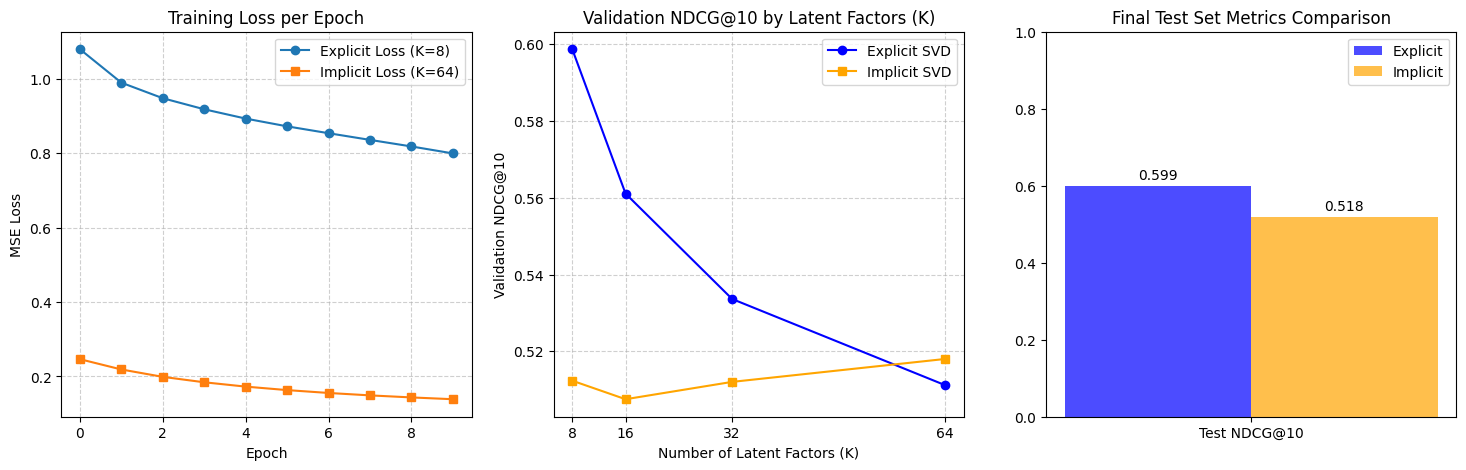

In [ ]:
# -----------------------------
# Setup Storage Variables
# -----------------------------
explicit_metrics = {}
implicit_metrics = {}




flag = None

model, results, best_eval_for_k = hyperparameter_tuning_ncf(training_split, validation_set, flag, num_users, num_items)

print(results)
print(best_eval_for_k)

# -----------------------------
# EXPERIMENT 1: Explicit SVD
# -----------------------------
print("\n" + "="*30)
print("---- Explicit SVD ----")
print("="*30)

b_items, q_items, b_users, p_users, results, best_eval_for_k = hyperparameter_tuning(
    training_split, validation_set, "explicit", num_users, num_items
)

# 🔑 Calculate global mean from the training data for the test evaluation
global_mean_exp = calculate_global_mean(training_split)

best_k_explicit = max(best_eval_for_k, key=best_eval_for_k.get)
explicit_losses = results[best_k_explicit]
explicit_eval_k = best_eval_for_k

# 🔑 Pass global_mean_exp into rmse and NDCG
test_rmse_exp = rmse(test_set, b_users, b_items, p_users, q_items, global_mean_exp)
test_ndcg_exp = evaluate_explicit_ndcg(training_split, test_set, ratings_df.MovieID.max(), b_users, b_items, p_users, q_items, global_mean_exp, K=10)

explicit_metrics['RMSE'] = test_rmse_exp
explicit_metrics['NDCG@10'] = test_ndcg_exp

print(f"Explicit SVD Final Test RMSE: {test_rmse_exp:.4f}")
print(f"Explicit SVD Final Test NDCG@10: {test_ndcg_exp:.4f}")

# -----------------------------
# EXPERIMENT 2: Implicit SVD
# -----------------------------
print("\n" + "="*30)
print("---- Implicit SVD ----")
print("="*30)

# Convert validation and test sets to implicit feedback (Rating = 1)
for i in test_set:
    test_set[i].rating = 1
for i in validation_set:
    validation_set[i].rating = 1

b_items, q_items, b_users, p_users, results, best_eval_for_k = hyperparameter_tuning(
    implicit_training_split, validation_set, "implicit", num_users, num_items
)

# Extract best K and its corresponding loss history
best_k_implicit = max(best_eval_for_k, key=best_eval_for_k.get)
implicit_losses = results[best_k_implicit]
implicit_eval_k = best_eval_for_k

# Final Test Evaluation
global_mean_imp = calculate_global_mean(implicit_training_split)
test_rmse_imp = rmse(test_set, b_users, b_items, p_users, q_items, global_mean_imp)
test_ndcg_imp = evaluate_implicit_ndcg(implicit_training_split, test_set, ratings_df.MovieID.max(), b_users, b_items, p_users, q_items, global_mean_imp, K=10)

implicit_metrics['RMSE'] = test_rmse_imp
implicit_metrics['NDCG@10'] = test_ndcg_imp

print(f"Implicit SVD Final Test RMSE: {test_rmse_imp:.4f}")
print(f"Implicit SVD Final Test NDCG@10: {test_ndcg_imp:.4f}")


# ==========================================
# PLOTTING DASHBOARD
# ==========================================
print("\nGenerating comparative plots...")

# Set up a 1x3 grid for our plots to make them look cohesive
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Training Loss per Epoch ---
axes[0].plot(explicit_losses, label=f"Explicit Loss (K={best_k_explicit})", marker='o')
axes[0].plot(implicit_losses, label=f"Implicit Loss (K={best_k_implicit})", marker='s')
axes[0].set_title("Training Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# --- Plot 2: Validation NDCG vs. Latent Factors (K) ---
# Ensure K values are sorted for a clean line plot
k_vals_exp = sorted(list(explicit_eval_k.keys()))
ndcg_vals_exp = [explicit_eval_k[k] for k in k_vals_exp]

k_vals_imp = sorted(list(implicit_eval_k.keys()))
ndcg_vals_imp = [implicit_eval_k[k] for k in k_vals_imp]

axes[1].plot(k_vals_exp, ndcg_vals_exp, label="Explicit SVD", marker='o', color='blue')
axes[1].plot(k_vals_imp, ndcg_vals_imp, label="Implicit SVD", marker='s', color='orange')
axes[1].set_title("Validation NDCG@10 by Latent Factors (K)")
axes[1].set_xlabel("Number of Latent Factors (K)")
axes[1].set_ylabel("Validation NDCG@10")
axes[1].set_xticks(k_vals_exp) # Snap x-ticks to actual K values
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# --- Plot 3: Final Test Set Comparison (Bar Chart) ---
labels = ['Test NDCG@10']
# Only grab the NDCG scores
explicit_bars = [explicit_metrics['NDCG@10']]
implicit_bars = [implicit_metrics['NDCG@10']]

x = np.arange(len(labels))
width = 0.35

# Create grouped bars just for NDCG
rects1 = axes[2].bar(x - width/2, explicit_bars, width, label='Explicit', color='blue', alpha=0.7)
rects2 = axes[2].bar(x + width/2, implicit_bars, width, label='Implicit', color='orange', alpha=0.7)

axes[2].set_title("Final Test Set Metrics Comparison")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
# Set Y-axis to top out at 1.0 since NDCG is a percentage
axes[2].set_ylim(0, 1.0)
axes[2].legend()

# Add values on top of the bars
for rect in rects1 + rects2:
    height = rect.get_height()
    axes[2].annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

# Test the ranking helper
print("\nRanking Helper Output:")
print(ndcg_from_ranking([1, 2, 100], target_item=100, rel=1.0))

0.09188356868262311


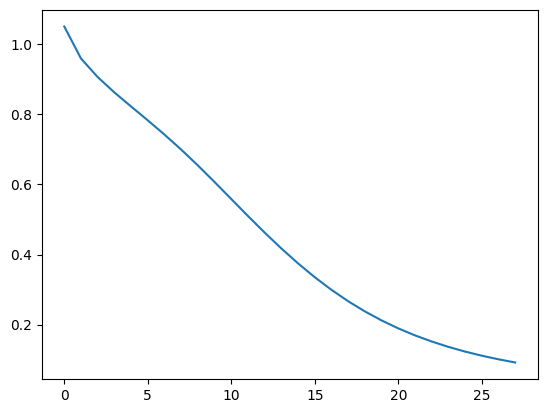

In [ ]:

gamma = 0.01
lambda4 = 0.02
#mu = ratings.mean()
mu = 0
normalise = 0
for user, ratings in training_split.items():
    for rating in ratings:
      r_ui = rating.rating
      mu += (r_ui)
    normalise += len(ratings)

mu = mu / normalise



max_iterations = 100
i = 0
loss = 1
loss_threshold = 0.1

loss_iterations = []
ii = 0

while (i < max_iterations and loss > loss_threshold):

    loss = 0

    for user, ratings in training_split.items():
        for rating in ratings:
            item = rating.movie_id
            r_ui = rating.rating
            # prediction
            pred = mu + b_users[user] + b_items[item] + np.dot(p_users[user], q_items[item])


            # error
            e_ui = r_ui - pred

            # updates
            b_users[user] += gamma * (e_ui - lambda4 * b_users[user])
            b_items[item] += gamma * (e_ui - lambda4 * b_items[item])

            q_items[item] += gamma * (e_ui * p_users[user] - lambda4 * q_items[item])
            p_users[user] += gamma * (e_ui * q_items[item] - lambda4 * p_users[user])

            loss += e_ui**2


    loss = loss / normalise
    loss_iterations.append(loss)
    i += 1

#plot loss
plt.plot(loss_iterations)
print(loss_iterations[-1])


In [ ]:

loss = 0

for user, ratings in training_split.items():
  for rating in ratings:
    item = rating.movie_id
    r_ui = rating.rating
            # prediction
    pred = mu + b_users[user] + b_items[item] + np.dot(p_users[user], q_items[item])
    e_ui = r_ui - pred
    loss += e_ui**2

loss = loss / normalise

print(loss)


0.08229196432460843


In [ ]:
#HR@10

#sample 100 from users that are unrated.
#
#for each user i interlvall [0,10^6] kolla om rated om inte ratad ta 100. Kolla om den redan rated && tagit med den redan.
#sen predict värdne för 100 indexarna exklusive test då vi redan vet
# sen hoppas på att test finns med bland dessa

#hr = 0

#for user, ratings in training_split.items():
#  seen_samples = set()
 # prediction_list = np.zeros(100)
  #while len(seen_samples) < 100:
   # sample = np.random.randint(0, movies_df.MovieID.max() + 1)
    #if sample not in seen_samples:
     # unfucked_columns = [obj.movie_id for obj in ratings]
      #if sample not in unfucked_columns:
       # seen_samples.add(sample)

  #for sample in seen_samples:
   # pred = np.dot(p_users[user], q_items[sample]) + mu + b_users[user] + b_items[sample]
    #prediction_list.append(pred)
  #rate test movie
  #test_val = test_set[user]
  #prediction_list.append()
  #test_val = test_set[user]



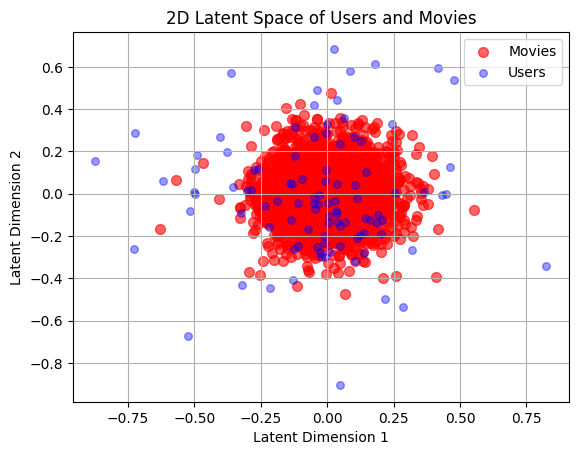

In [ ]:
import matplotlib.pyplot as plt


# 0-based indexing for arrays
first_users_idx = first_users - 1  # if p_users is 0-based

# Plot movies
plt.scatter(q_items[:, 0], q_items[:, 1], c='red', alpha=0.6, label='Movies', s=50)

# Plot only the first 1000 users
plt.scatter(p_users[first_users_idx, 0], p_users[first_users_idx, 1], c='blue', alpha=0.4, label='Users', s=30)

plt.title("2D Latent Space of Users and Movies")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.legend()
plt.grid(True)
plt.show()